In [ ]:
import pandas as pd; df = pd.read_excel('/content/Sample - Superstore.xlsx'); df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-08-11 00:00:00,2016-11-11 00:00:00,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-12-06 00:00:00,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-11-10 00:00:00,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


# Superstore Optimization: Strategic Revenue & Profitability Analysis

## Executive Summary
This project analyzes operational transaction data to diagnose why high sales volumes are failing to yield healthy profit margins. While Technology lines drive core profitability, aggressive promotional discounting (scaling past 20%) is actively destroying value, particularly within the Central region and the Furniture category. By transitioning from gross volume targets to strict margin-protection thresholds, the business can safeguard its bottom line without sacrificing market presence.

In [ ]:
# 1. Check for missing values
print("--- Missing Values ---")
print(df.isnull().sum())

# 2. Convert Order Date to datetime format
df['Order Date'] = pd.to_datetime(df['Order Date'])

# 3. Check data types
print("\n--- Data Types ---")
print(df.dtypes[['Sales', 'Profit', 'Discount', 'Order Date']])

--- Missing Values ---
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64

--- Data Types ---
Sales                float64
Profit               float64
Discount             float64
Order Date    datetime64[ns]
dtype: object


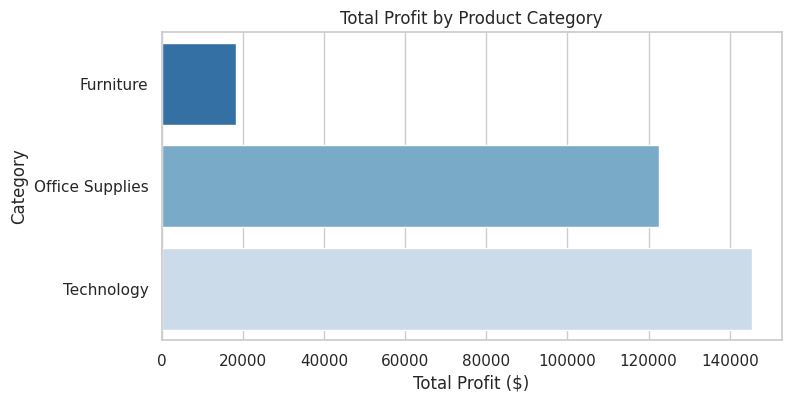

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Aggregate profit by Category
cat_data = df.groupby('Category')['Profit'].sum().reset_index()

# Plot the chart
plt.figure(figsize=(8, 4))
sns.barplot(x='Profit', y='Category', data=cat_data, hue='Category', palette='Blues_r', legend=False)
plt.title('Total Profit by Product Category')
plt.xlabel('Total Profit ($)')
plt.ylabel('Category')
plt.show()

Product Category Profitability Analysis

What it shows: Technology is heavily leading profitability, followed closely by Office Supplies, while Furniture lags significantly behind despite making up a large portion of operational volume.

Why it matters: The low margins in Furniture indicate high underlying costs or aggressive discounting issues. Leadership should focus expansion and inventory investments toward high-margin Technology lines.

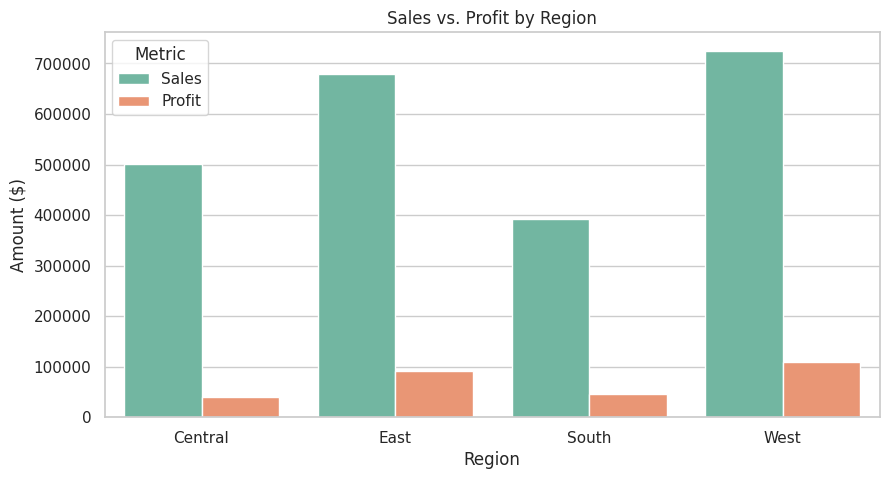

In [ ]:
# Aggregate Sales and Profit by Region
region_data = df.groupby('Region')[['Sales', 'Profit']].sum().reset_index()

# Melt data to make it easy for seaborn to plot side-by-side
region_melted = region_data.melt(id_vars='Region', value_vars=['Sales', 'Profit'],
                                 var_name='Metric', value_name='Amount')

# Plot the chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Region', y='Amount', hue='Metric', data=region_melted, palette='Set2')
plt.title('Sales vs. Profit by Region')
plt.ylabel('Amount ($)')
plt.show()

Regional Revenue Performance

What it shows: The Central region generates substantial sales revenue comparable to other major regions, yet its total profit yield is disproportionately low.

Why it matters: High revenue paired with weak profit points to severe operational inefficiencies, high shipping overheads, or over-discounting in Central states. Revenue alone is not a metric for health here.

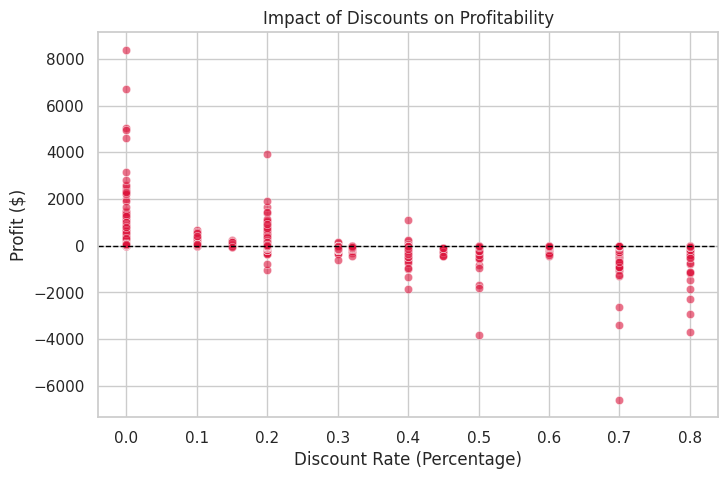

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Plot the correlation between Discount and Profit
plt.figure(figsize=(8, 5))
sns.scatterplot(x='Discount', y='Profit', data=df, alpha=0.6, color='crimson')
plt.axhline(0, color='black', linestyle='--', linewidth=1) # Baseline at $0 profit
plt.title('Impact of Discounts on Profitability')
plt.xlabel('Discount Rate (Percentage)')
plt.ylabel('Profit ($)')
plt.show()

Discount vs. Profitability Correlation

What it shows: As the discount rate scales past 20%, transactions rapidly drop below the zero-profit threshold, resulting in massive scaling losses.

Why it matters: This clearly indicates that promotional discounting is destructive rather than constructive for the bottom line. The store needs strict automated limits on maximum allowable discount clearances.

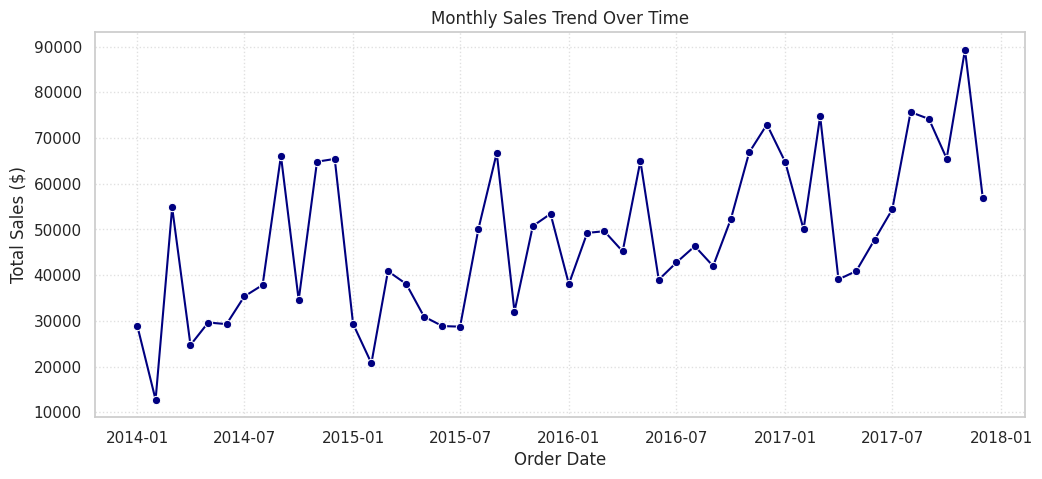

In [ ]:
# Group by Year-Month
time_data = df.groupby(df['Order Date'].dt.to_period('M'))['Sales'].sum().reset_index()
time_data['Order Date'] = time_data['Order Date'].dt.to_timestamp()

# Plot the trend
plt.figure(figsize=(12, 5))
sns.lineplot(x='Order Date', y='Sales', data=time_data, marker='o', color='navy')
plt.title('Monthly Sales Trend Over Time')
plt.xlabel('Order Date')
plt.ylabel('Total Sales ($)')
plt.grid(True, linestyle=':', alpha=0.6)
plt.show()

Seasonality and Sales Trends

What it shows: Sales exhibit a highly predictable, cyclical seasonal pattern, peaking intensely in the final months of every calendar year (Q4 holiday rush).

Why it matters: Operations and supply chain management can lean heavily into this predictability, ramping up inventory levels and temporary staffing ahead of September to maximize fulfillment performance during peak surges.

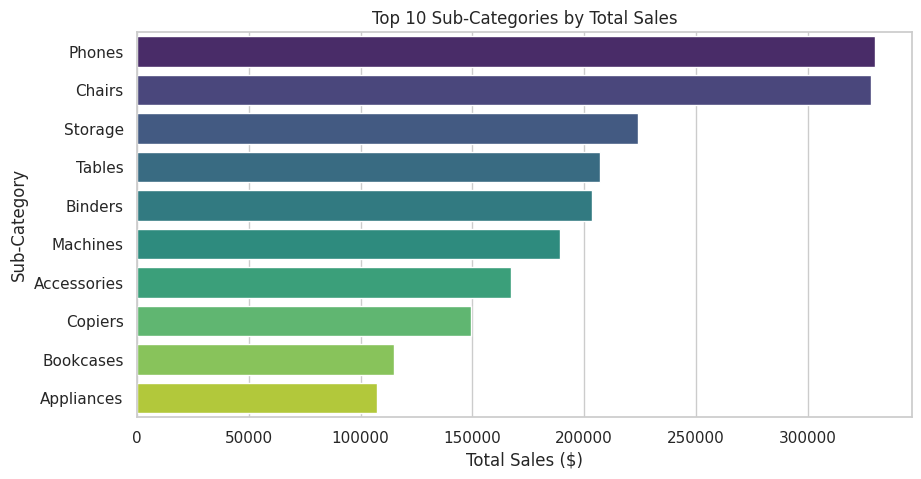

In [ ]:
# Find the top 10 Sub-Categories
top10_sub = df.groupby('Sub-Category')['Sales'].sum().reset_index()
top10_sub = top10_sub.sort_values(by='Sales', ascending=False).head(10)

# Plot the chart
plt.figure(figsize=(10, 5))
sns.barplot(x='Sales', y='Sub-Category', data=top10_sub, hue='Sub-Category', palette='viridis', legend=False)
plt.title('Top 10 Sub-Categories by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Sub-Category')
plt.show()

Core Sub-Category Sales Anchors

What it shows: Phones and Chairs dominate the gross transaction volumes of the business, generating the highest raw sales numbers.

Why it matters: These anchor products are critical revenue vectors that bring customers through the door. Keeping these core categories optimized ensures the business maintains healthy baseline market activity.